# Atmospheric Energy Budget
Below I check if I can recreate the atmospheric energy budget.

In [1]:
import copy
import sys
import os
import inspect
from matplotlib.lines import Line2D
import scipy.optimize
from scipy.interpolate import CubicSpline, UnivariateSpline
from scipy.ndimage import gaussian_filter1d

from isca_tools.papers.miyawaki_2022 import get_dmse_dt
from isca_tools.plot.base import line_masked_lw
from isca_tools.thesis.adiabat_theory import get_z_ft_approx
from isca_tools.thesis.profile_fitting import get_tropopause_lev_ind
from isca_tools.utils.base import mass_weighted_vertical_integral
from isca_tools.utils.fourier import coef_conversion, fourier_series
from isca_tools.utils.numerical import get_var_shift, fit_linear_zero_mean, spline_deriv_periodic
from isca_tools.utils.xarray import wrap_with_apply_ufunc, update_dim_slice, transpose_common_dims_like
from matplotlib.ticker import FuncFormatter, FixedLocator

# REMOTE - So can access functions in isca_tools which is in home/Isca directory
# sys.path.append(os.path.join(os.environ['HOME'], 'Isca'))
# LOCAL - So can access functions in isca_tools which is in StAndrews/Isca
sys.path.append(os.environ['PWD'])
import isca_tools
from isca_tools.utils.moist_physics import clausius_clapeyron_factor, sphum_sat, get_density, moist_static_energy
from isca_tools.utils.constants import kappa, L_v, c_p, c_p_ocean, rho_ocean, Stefan_Boltzmann, R, R_v, g, radius_earth
from isca_tools.utils import numerical, annual_mean
from isca_tools.utils.radiation import get_heat_capacity, frierson_sw_optical_depth, frierson_atmospheric_heating
from isca_tools.plot import colored_line, line_masked_lw
from isca_tools.thesis.surface_energy_budget_2layer import get_feedback_params, get_heat_cap_lambda_eff, \
    get_heat_cap_lambda_eff_approx
from isca_tools.thesis.surface_energy_budget_2layer2 import get_feedback_params_analytic
from isca_tools.thesis.surface_energy_budget_2layer2 import get_heat_cap_lambda_eff as get_heat_cap_lambda_eff2
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from tqdm.notebook import tqdm
from isca_tools.plot import fig_resize, update_fontsize, update_linewidth, savefig, label_subplots

from jobs.thesis_season.thesis_figs.utils import get_fourier_fit_xr, polyfit_phase_xr
import jobs.thesis_season.column.utils as utils

# Use custom matplotlib style for publishing
plt.style.use('/Users/joshduffield/Documents/StAndrews/Isca/jobs/tau_sweep/aquaplanet/publish_figures/publish.mplstyle')
ax_linewidth = plt.rcParams['axes.linewidth']

In [2]:
from time import perf_counter


def timed_step(label, func):
    """Run func(), print elapsed time, and return its result."""
    start = perf_counter()
    result = func()
    elapsed = perf_counter() - start
    print(f"{label:<55} {elapsed:8.2f} s")
    return result


get_dmse_dt_xr = utils.wrap_with_apply_ufunc(get_dmse_dt,
                                             input_core_dims=[['time', 'pfull'], ['time', 'pfull'], ['time', 'pfull'],
                                                              ['pfull'], ['time']],
                                             output_core_dims=[['time'], ['time']])

In [84]:
# exp_name = [f"thesis_season/column/depth={i}/k=1_abs=0_2" for i in [5, 20]]
# exp_name = [f"thesis_season/column/depth={i}/odp_const" for i in [5, 20]]
# exp_name = [f"thesis_season/column/depth={i}/wind_moist" for i in [5, 20]]
depth = 5
exp_name = f'thesis_season/depth={depth}/wind_moist'
# exp_name = f'tau_sweep/aquaplanet/depth=1/k=1'
# exp_name = [f"thesis_season/column/depth={i}/no_wind_dry_long_output" for i in [5, 20]]
vars_keep = ['temp', 'ps', 'sphum', 'vcomp', 'olr', 'swdn_toa', 'swdn_sfc', 'lwdn_sfc', 'lwup_sfc', 'flux_t',
             'flux_lhe', 't_surf', 'height']
lat_min = 30
lat_max = 90
ds_base = isca_tools.load_dataset(exp_name, first_month_file=121).sel(lat=slice(lat_min, lat_max))
ds_base = ds_base[vars_keep]
ds_base = timed_step("Load ds_base into memory", lambda: ds_base.load())
# MSE transport flux, remember 1000 times as to convert from kJ/kg
ds_base['dse_transport_flux'] = mass_weighted_vertical_integral(
    ds_base.vcomp * moist_static_energy(ds_base.temp, 0 * ds_base.sphum, ds_base.height),
    ds_base.pfull * 100, norm=False, lev_dim="pfull") * 1000
ds_base['q_transport_flux'] = mass_weighted_vertical_integral(
    ds_base.vcomp * moist_static_energy(0 * ds_base.temp, ds_base.sphum, 0 * ds_base.height),
    ds_base.pfull * 100, norm=False, lev_dim="pfull") * 1000
ds_base['mse_transport_flux'] = mass_weighted_vertical_integral(
    ds_base.vcomp * moist_static_energy(ds_base.temp, ds_base.sphum, ds_base.height),
    ds_base.pfull * 100, norm=False, lev_dim="pfull") * 1000

# Compute tendency at each lon, and year
ds_base['mse_int'] = mass_weighted_vertical_integral(moist_static_energy(ds_base.temp, ds_base.sphum, ds_base.height),
                                                     ds_base.pfull * 100, norm=False, lev_dim="pfull") * 1000
ds_base['mse_no_z_int'] = mass_weighted_vertical_integral(
    moist_static_energy(ds_base.temp, ds_base.sphum, 0 * ds_base.height),
    ds_base.pfull * 100, norm=False, lev_dim="pfull") * 1000

ds_base['temp_col'] = mass_weighted_vertical_integral(ds_base.temp, ds_base.pfull * 100, 'pfull', simpson_method=False)
ds_base = ds_base.sel(pfull=np.inf, method='nearest')  # don't need vertical dimension anymore after the above integrals
ds = utils.get_annual_zonal_mean(ds_base)  # also smooths by 50 days
ds = timed_step("Load ds into memory", lambda: ds.load())

Load ds_base into memory                                   12.12 s
Load ds into memory                                         0.00 s


In [85]:
# Get sigma levels
namelist = isca_tools.load_namelist(exp_name)
sigma_levels_half = np.asarray(namelist['vert_coordinate_nml']['bk'])
sigma_levels_full = np.convolve(sigma_levels_half, np.ones(2) / 2, 'valid')
albedo = namelist['mixed_layer_nml']['albedo_value']
# ds['sigma_lev'] = ds.temp.isel(time=0, lat=0) * 0 + sigma_levels_full
# ds['p_lev'] = ds.sigma_lev * ds.ps.mean()

In [86]:
def spline_deriv(x, y, s=None):
    spl = UnivariateSpline(x, y, s=s)
    return spl.derivative()(x)

def periodic_rolling_mean(da, dim, window):
    if window % 2 == 0:
        raise ValueError("Use an odd window for a centred rolling mean.")

    half_window = window // 2

    return (
        da
        .pad({dim: (half_window, half_window)}, mode="wrap")
        .rolling({dim: window}, center=True, min_periods=window)
        .mean()
        .isel({dim: slice(half_window, -half_window)})
    )

gaussian_filter1d_xr = utils.wrap_with_apply_ufunc(gaussian_filter1d,
                                                   input_core_dims=[['time']],
                                                   output_core_dims=[['time']])


spline_deriv_xr = utils.wrap_with_apply_ufunc(spline_deriv,
                                              input_core_dims=[['lat'], ['lat']],
                                              output_core_dims=[['lat']])
cos_lat = np.asarray(np.cos(np.deg2rad(ds.lat)))

In [87]:
for key in ['dse', 'q', 'mse']:
    var = ds[f"{key}_transport_flux"] * cos_lat
    sf = np.abs(var).mean()
    ds[f"{key}_conv"] = -spline_deriv_xr(np.deg2rad(ds.lat), var / sf, s=None) * sf / (radius_earth * cos_lat)

spline_deriv_periodic_xr = utils.wrap_with_apply_ufunc(spline_deriv_periodic,
                                                       input_core_dims=[['time'], ['time']],
                                                       output_core_dims=[['time']])
for key in ['mse', 'mse_no_z']:
    # ds[f'{key}_tend'] = spline_deriv_periodic_xr(ds.time * utils.day_seconds, ds[f"{key}_int"])
    ds[f'{key}_tend'] = spline_deriv_periodic_xr(ds.time * utils.day_seconds, gaussian_filter1d_xr(ds[f"{key}_int"], sigma=10.0, mode='wrap'))
    # ds[f'{key}_tend'] = spline_deriv_periodic_xr(ds.time * utils.day_seconds, periodic_rolling_mean(ds[f"{key}_int"], 'time', 21))
ds['flux_rhs'] = frierson_atmospheric_heating(ds, albedo) + ds.flux_t + ds.flux_lhe
ds['conv_total'] = ds['mse_no_z_tend'] - ds.flux_rhs
# vm = moist_static_energy(ds.temp, ds.sphum, ds.height)*1000 * ds.vcomp
# vm_integ = mass_weighted_vertical_integral(vm, ds.p_lev, 'pfull', norm=False)
# sf = np.abs(vm_integ.mean())
# var = spline_deriv_xr(np.deg2rad(ds.lat), vm_integ/sf, s=None) * sf * cos_lat/ (radius_earth * cos_lat)

### Atmospheric Energy Budget Closure
It is quite common to take the advection terms in the atmospheric energy budget as a residual term. This term is shown by the black line below. However, an issue with this is that you cannot split up advection into humidity and temperature terms. So I also try manually to compute the advection terms in the following way:

* For the raw dataset (all days in all years and longitudes) I compute $<vh>$ which is the mass weighted vertical integral of meridional MSE transport flux.
* Take the zonal-annual mean with 50 day smoothing, so now just 360 values for each latitude. Take the resultant $[<vh>]$ and compute the meridional derivative of that according to $-\frac{1}{a\cos \phi} \frac{ \partial ([<vh>]\cos \phi)}{\partial \phi}$

We see that the approximation does a reasonable job in summer at matching the residual method, but not very good in winter. Maybe this is because there is a lot more transport of MSE due to eddies in winter, which is somewhat negelcted in this average, typical year view point.

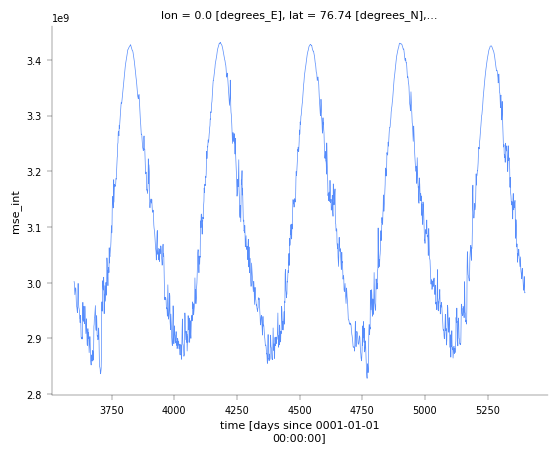

In [88]:
ds_base.mse_int.isel(lat=-5, lon=0).plot()

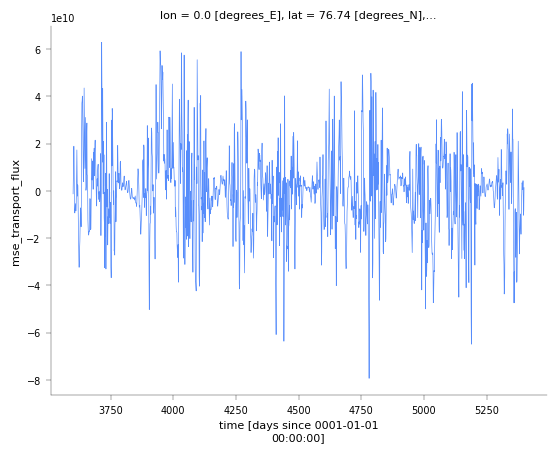

In [89]:
ds_base.mse_transport_flux.isel(lat=-5, lon=0).plot()

(-1.0, 360.0)

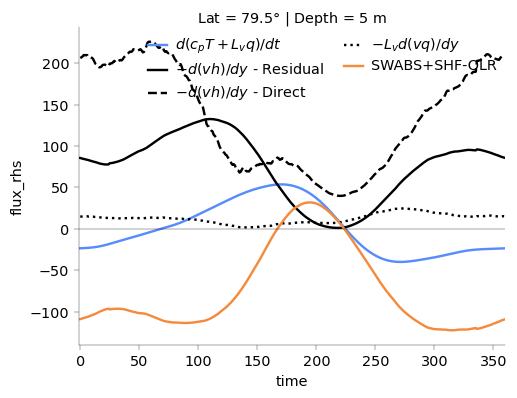

In [90]:
fig, ax = plt.subplots(1, 1)
fig_resize(fig, utils.width['two_col'])
lat_ind = -4
ds.mse_no_z_tend.isel(lat=lat_ind).plot(ax=ax, label='$d(c_pT+L_vq)/dt$')
ds.conv_total.isel(lat=lat_ind).plot(color='k', label='$-d(vh)/dy$ - Residual')
ds.mse_conv.isel(lat=lat_ind).plot(color='k', linestyle='--', label='$-d(vh)/dy$ - Direct')
# ds.dse_conv.isel(lat=lat_ind).plot(color='k', linestyle='-.')
ds.q_conv.isel(lat=lat_ind).plot(color='k', linestyle=':', label='$-L_vd(vq)/dy$')
ds.flux_rhs.isel(lat=lat_ind).plot(label='SWABS+SHF-OLR')
update_linewidth(fig)
ax.legend(ncol=2)
ax.axhline(0, color='k', lw=ax_linewidth)
ax.set_title(f'Lat = {ds.lat.values[lat_ind]:.1f}$\degree$ | Depth = {depth} m', y=0.99)
update_fontsize(fig, 6)
ax.set_xlim(-1, 360)
# (ds.flux_rhs+ds.mse_conv).isel(lat=lat_ind).plot()

### Relating meridional advection seasonality to local atmospheric temperature seasonality

The advective tendency term I just take as the residual between the RHS and LHS of the atmospheric energy budget.

Below I say that the advective term is linearly related to temperature and compute the error i.e., $\frac{1}{g}\int v\frac{dh}{dy}dp \approx \lambda_{adv}T_{col} + \text{const}$.

I use the column weighted temperature rather than lowest model level, as takes account of all levels. It appears this is a good approximation around $55\degree$ (and further south than this if only considering the first harmonic).

At higher latitudes, we see there is a phase delay between the seasonality of the column temperature and advective flux of around 10 days.

In [61]:
# Take annual harmonic of all variables for simplicity
ds_ah = ds.copy(deep=True)
for key in ds_ah:
    if 'time' in ds[key].dims:
        try:
            ds_ah[key] = get_fourier_fit_xr(ds_ah.time, ds_ah[key], n_harmonics=1, pad_coefs_phase=True)[0]
        except ValueError:
            print(key)

In [62]:
fit_linear_zero_mean_xr_1 = utils.wrap_with_apply_ufunc(
    lambda x1, y: fit_linear_zero_mean(x1, y, x2=None)[0],
    input_core_dims=[['time'], ['time']],
    output_core_dims=[[]],
)

fit_linear_zero_mean_xr_2 = utils.wrap_with_apply_ufunc(
    lambda x1, y, x2: fit_linear_zero_mean(x1, y, x2=x2),
    input_core_dims=[['time'], ['time'], ['time']],
    output_core_dims=[[], []],
)


def get_fit_coef(x1, y, x2=None):
    # Returns single fitting coefficient, i.e., c such that y=cx
    if x2 is None:
        return fit_linear_zero_mean_xr_1(x1 - x1.mean(dim='time'), y - y.mean(dim='time'))
    else:
        return fit_linear_zero_mean_xr_2(x1 - x1.mean(dim='time'), y - y.mean(dim='time'), x2 - x2.mean(dim='time'))

In [63]:
ds['advect_coef'] = get_fit_coef(ds.temp_col, ds.conv_total)
ds_ah['advect_coef'] = get_fit_coef(ds_ah.temp_col, ds_ah.conv_total)
ds['advect_error'] = ds.conv_total - ds.conv_total.mean(dim='time') - ds['advect_coef'] * (
            ds.temp_col - ds.temp_col.mean(dim='time'))
ds['advect_error'] = np.abs(ds.advect_error).mean(dim='time')
ds_ah['advect_error'] = ds_ah.conv_total - ds_ah.conv_total.mean(dim='time') - \
                        ds_ah['advect_coef'] * (ds_ah.temp_col - ds_ah.temp_col.mean(dim='time'))
ds_ah['advect_error'] = np.abs(ds_ah.advect_error).mean(dim='time')

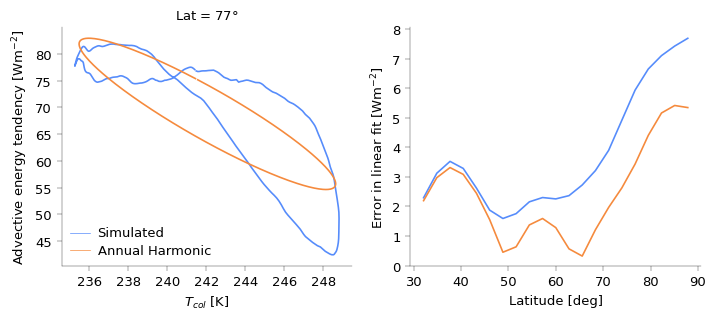

In [71]:
fig, ax = plt.subplots(1, 2)
fig_resize(fig, utils.width['two_col'] * 1.5)
lat_ind = -5
ax[0].plot(ds.temp_col.isel(lat=lat_ind), ds.conv_total.isel(lat=lat_ind), label='Simulated')
ax[0].plot(ds_ah.temp_col.isel(lat=lat_ind), ds_ah.conv_total.isel(lat=lat_ind), label='Annual Harmonic')
# ax[0].plot(ds.temp_col.isel(lat=lat_ind), ds.mse_conv.isel(lat=lat_ind), color='C0', linestyle=':')
# ax[0].plot(ds_ah.temp_col.isel(lat=lat_ind), ds_ah.mse_conv.isel(lat=lat_ind), color='C1', linestyle=':')
ax[1].plot(ds.lat, ds.advect_error)
ax[1].plot(ds.lat, ds_ah.advect_error)
ax[0].set_ylabel('Advective energy tendency [Wm$^{-2}$]')
ax[0].set_xlabel('$T_{col}$ [K]')
ax[0].set_title(f'Lat = {ds.lat[lat_ind]:.0f}$\degree$')
ax[1].set_xlabel(utils.label_lat)
ax[1].set_ylabel('Error in linear fit [Wm$^{-2}$]')
ax[0].legend()
ax[1].set_ylim(0, ax[1].get_ylim()[1])
update_linewidth(fig)
update_fontsize(fig)
if ds.conv_total.isel(lat=lat_ind).min() < 0:
    ax[0].axhline(0, color='k', lw=ax_linewidth)
plt.show()

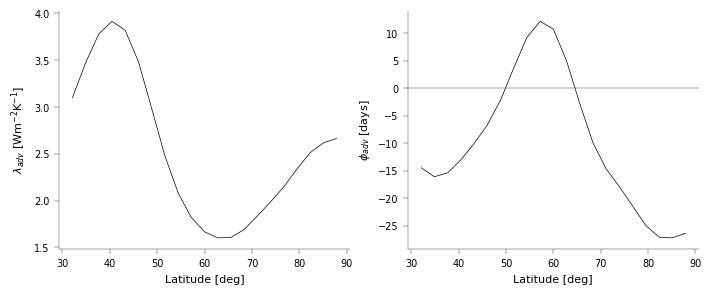

In [65]:
# Remember high temp means low advection hence use -tend in fitting so get positive amp coef
ds_ah['advect_coef_amp'], ds_ah['advect_coef_phase'] = utils.get_fit_coef_complex(-ds_ah.conv_total, ds_ah.temp_col,
                                                                                  ds.time)
omega = 2 * np.pi / (utils.day_seconds * ds.time.size)

fig, ax = plt.subplots(1, 2, sharex=True)
fig_resize(fig, utils.width['two_col'] * 1.5)
ax[0].plot(ds_ah.lat, ds_ah['advect_coef_amp'], color='k')
ax[1].plot(ds_ah.lat, np.arctan(ds_ah['advect_coef_phase']) / omega / utils.day_seconds, color='k')
ax[0].set_ylabel('$\lambda_{adv}$ [Wm$^{-2}$K$^{-1}$]')
ax[1].set_ylabel('$\phi_{adv}$ [days]')
ax[0].set_xlabel(utils.label_lat)
ax[1].set_xlabel(utils.label_lat)
ax[1].axhline(0, color='k', lw=ax_linewidth)
plt.show()